In [2]:
# Nếu chạy lần đầu trên Colab/local, mở comment dòng dưới để cài dependency.
# !pip install opencv-python ultralytics transformers torch pillow matplotlib

In [3]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from transformers import pipeline
from ultralytics import YOLO

/Users/paulnguyen/Documents/GitHub/Master/Python4Dev/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
model = YOLO('yolo26n.pt')

In [5]:
# model.train(
#   data='data/PlantDocv4/data.yaml',
#   epochs=5,
#   batch=64,
#   imgsz=640,
#   device='mps'
# )

# model.save('yolo26nt_finetuned.pt')

In [ ]:
# model_ft = YOLO('data/yolo11n_finetuned.pt')

# metrics = model_ft.val(
#   data="data/PlantDocv4/data.yaml",
#   split='test',
#   verbose=True,
#   workers=4
# )


# print(metrics)

Ultralytics 8.4.67 🚀 Python-3.13.5 torch-2.12.0 CPU (Apple M2 Pro)
YOLO11n summary (fused): 100 layers, 2,588,002 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 145.9±132.4 MB/s, size: 39.4 KB)
val: Scanning /Users/paulnguyen/Documents/GitHub/Master/Python4Dev/day-5/data/PlantDocv4/test/labels.cache... 246 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 246/246 19.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 87% ━━━━━━━━━━── 14/16 4.6s/it 43.1s<9.1ss


KeyboardInterrupt: 

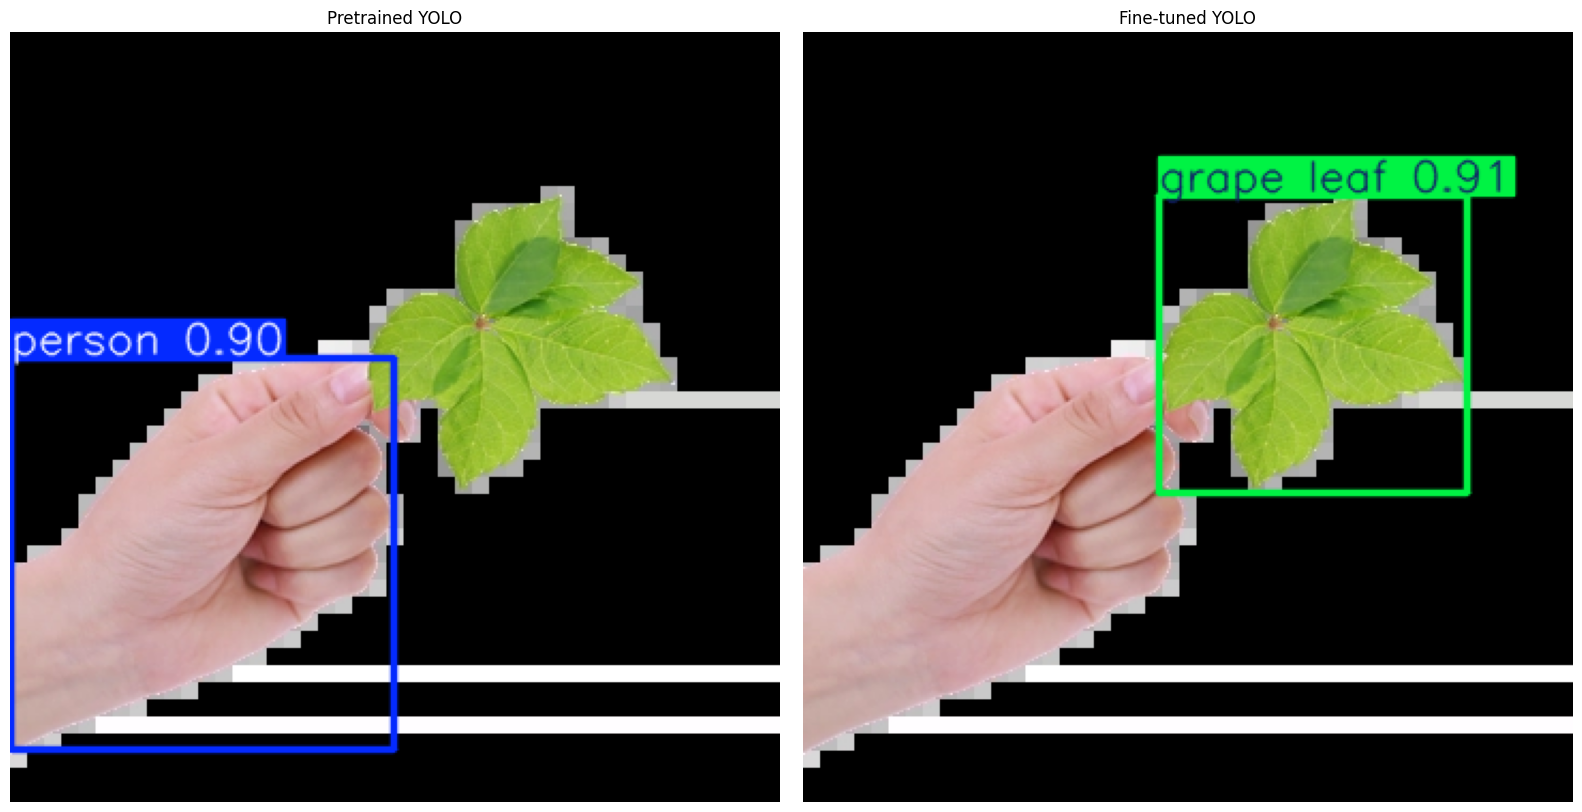

In [13]:
def resolve_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    return Path(candidates[0])

model_pre = YOLO(str(resolve_path('yolo26n.pt', 'day-5/yolo26n.pt')))
model_finetuned = YOLO(str(resolve_path('data/yolo11n_finetuned.pt', 'day-5/data/yolo11n_finetuned.pt')))

image_path = resolve_path('/Users/paulnguyen/Downloads/pngtree-hand-holding-green-leaf-photography-vector-png-image_17055404.webp', 'day-5/data/x.avif')

results_pre = model_pre.predict(str(image_path), imgsz=640, save=False, verbose=False)
results_ft = model_finetuned.predict(str(image_path), imgsz=640, save=False, verbose=False)

img_pre = cv2.cvtColor(results_pre[0].plot(), cv2.COLOR_BGR2RGB)
img_ft = cv2.cvtColor(results_ft[0].plot(), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img_pre)
axes[0].set_title('Pretrained YOLO', fontsize=12)
axes[0].axis('off')

axes[1].imshow(img_ft)
axes[1].set_title('Fine-tuned YOLO', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()